In [112]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Clustering and preprocessing tools
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler

## Load Excel File

In [113]:
# Load source dataset
df = pd.read_excel("AmesHousing.xlsx")

# Quick shape check
print("rows and columns", df.shape)

# Preview first records
df.head(5)

rows and columns (2930, 12)


,ID,SalePrice,Garage,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,Neighborhood,House Style
0,1,215000,yes,6,1656,1080.0,31770,1960,1,3,NAmes,1Story
1,2,105000,yes,5,896,882.0,11622,1961,1,2,NAmes,1Story
2,3,172000,yes,6,1329,1329.0,14267,1958,1,3,NAmes,1Story
3,4,244000,yes,7,2110,2110.0,11160,1968,2,3,NAmes,1Story
4,5,189900,yes,5,1629,928.0,13830,1997,2,3,Gilbert,2Story


## One-hot enconding for categorical columns (Neighborhood, House Style)

In [129]:
# Encode categorical columns for clustering input
df_hot_encoded = pd.get_dummies(
    df,
    columns=["House Style", "Neighborhood", 'Garage'],
    drop_first=True,
)

# Validate encoded table size and sample rows
print("one-hot shape", df_hot_encoded.shape)
df_hot_encoded.head(5)

one-hot shape (2930, 44)


,ID,SalePrice,Overall Qual,Gr Liv Area,Total Bsmt SF,Lot Area,Year Built,Full Bath,Bedroom AbvGr,House Style_1.5Unf,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Garage_yes
0,1,215000,6,1656,1080.0,31770,1960,1,3,False,...,False,False,False,False,False,False,False,False,False,True
1,2,105000,5,896,882.0,11622,1961,1,2,False,...,False,False,False,False,False,False,False,False,False,True
2,3,172000,6,1329,1329.0,14267,1958,1,3,False,...,False,False,False,False,False,False,False,False,False,True
3,4,244000,7,2110,2110.0,11160,1968,2,3,False,...,False,False,False,False,False,False,False,False,False,True
4,5,189900,5,1629,928.0,13830,1997,2,3,False,...,False,False,False,False,False,False,False,False,False,True


## Feature tries for clustering

In [131]:
# Define multiple feature combinations to compare cluster quality
datasets = [
    ["Year Built", "Full Bath"] + list(df_hot_encoded.filter(like="House Style").columns),
    [ "Lot Area", "SalePrice", "Overall Qual"] +  list(df_hot_encoded.filter(like="Garage").columns),
    ["Lot Area", "Overall Qual"] + list(df_hot_encoded.filter(like="House Style").columns),
    ["Year Built", "Bedroom AbvGr"] + list(df_hot_encoded.filter(like="Neighborhood").columns),
    ["Gr Liv Area", "Full Bath"] + list(df_hot_encoded.filter(like="Neighborhood").columns),
]

# Print each try to keep track of the experiment setup
for idx, features in enumerate(datasets, start=1):
    print(f"Try {idx}: {features}")

Try 1: ['Year Built', 'Full Bath', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin', 'House Style_2.5Unf', 'House Style_2Story', 'House Style_SFoyer', 'House Style_SLvl']
Try 2: ['Lot Area', 'SalePrice', 'Overall Qual', 'Garage_yes']
Try 3: ['Lot Area', 'Overall Qual', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin', 'House Style_2.5Unf', 'House Style_2Story', 'House Style_SFoyer', 'House Style_SLvl']
Try 4: ['Year Built', 'Bedroom AbvGr', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_Greens', 'Neighborhood_GrnHill', 'Neighborhood_IDOTRR', 'Neighborhood_Landmrk', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Nei

## Run KMeans for each feature try

In [132]:
# Store full output for each feature try
results = []

# Hard-coded k value (change this based on your own analysis)
current_k = 4

for dataset_index, features in enumerate(datasets, start=1):
    # Keep only required columns and remove missing rows
    clustering_df = df_hot_encoded[features].dropna().copy()

    # Scale features so distance-based clustering behaves well
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(clustering_df)

    # Build elbow data (range of k and corresponding inertias)
    elbow_k_values = list(range(2, 21))
    elbow_inertias = []

    for k in elbow_k_values:
        km_elbow = KMeans(n_clusters=k, random_state=42, n_init=20)
        km_elbow.fit(X_scaled)
        elbow_inertias.append(km_elbow.inertia_)

    # Fit KMeans with your chosen fixed k
    km = KMeans(n_clusters=current_k, random_state=42, n_init=20)
    labels_k = km.fit_predict(X_scaled)
    current_silhouette = silhouette_score(X_scaled, labels_k)

    # Compute distance from each sample to its nearest center
    all_distances = euclidean_distances(X_scaled, km.cluster_centers_)
    min_distances = all_distances.min(axis=1)

    cluster_distance_series = pd.Series(
        min_distances,
        index=clustering_df.index,
        name="distance_to_center",
    )

    # Compute mean distance per cluster
    cluster_distance_mean = (
        pd.DataFrame({
            "cluster": labels_k,
            "distance_to_center": min_distances,
        })
        .groupby("cluster")["distance_to_center"]
        .mean()
        .rename("mean_distance")
    )

    # Convert cluster centers back to original scale for readability
    centers_original = scaler.inverse_transform(km.cluster_centers_)
    cluster_centers_df = pd.DataFrame(centers_original, columns=features)
    cluster_centers_df.insert(0, "cluster", range(current_k))
    cluster_centers_df.insert(0, "dataset_index", dataset_index)

    # Save everything needed for later plots and tables
    results.append({
        "dataset_index": dataset_index,
        "features": features,
        "data": clustering_df,
        "scaler": scaler,
        "X_scaled": X_scaled,
        "current_k": current_k,
        "current_silhouette": current_silhouette,
        "model": km,
        "labels": labels_k,
        "distance_series": cluster_distance_series,
        "distance_mean": cluster_distance_mean,
        "centers_df": cluster_centers_df,
        "elbow_k_values": elbow_k_values,
        "elbow_inertias": elbow_inertias,
    })

# Build a compact comparison table for all tries
results_summary = pd.DataFrame([
    {
        "dataset_index": run["dataset_index"],
        "num_features": len(run["features"]),
        "current_k": run["current_k"],
        "current_silhouette": run["current_silhouette"],
        "avg_distance": run["distance_series"].mean(),
    }
    for run in results
]).sort_values("current_silhouette", ascending=False)

results_summary.reset_index(drop=True)

,dataset_index,num_features,current_k,current_silhouette,avg_distance
0,2,4,4,0.470178,0.911240
1,3,9,4,0.464741,1.362829
2,1,9,4,0.429125,1.628960
3,4,29,4,0.134336,4.236352
4,5,29,4,0.115950,4.196594


## Elbow, 2D scatter, and PCA scatter plots (all tries)

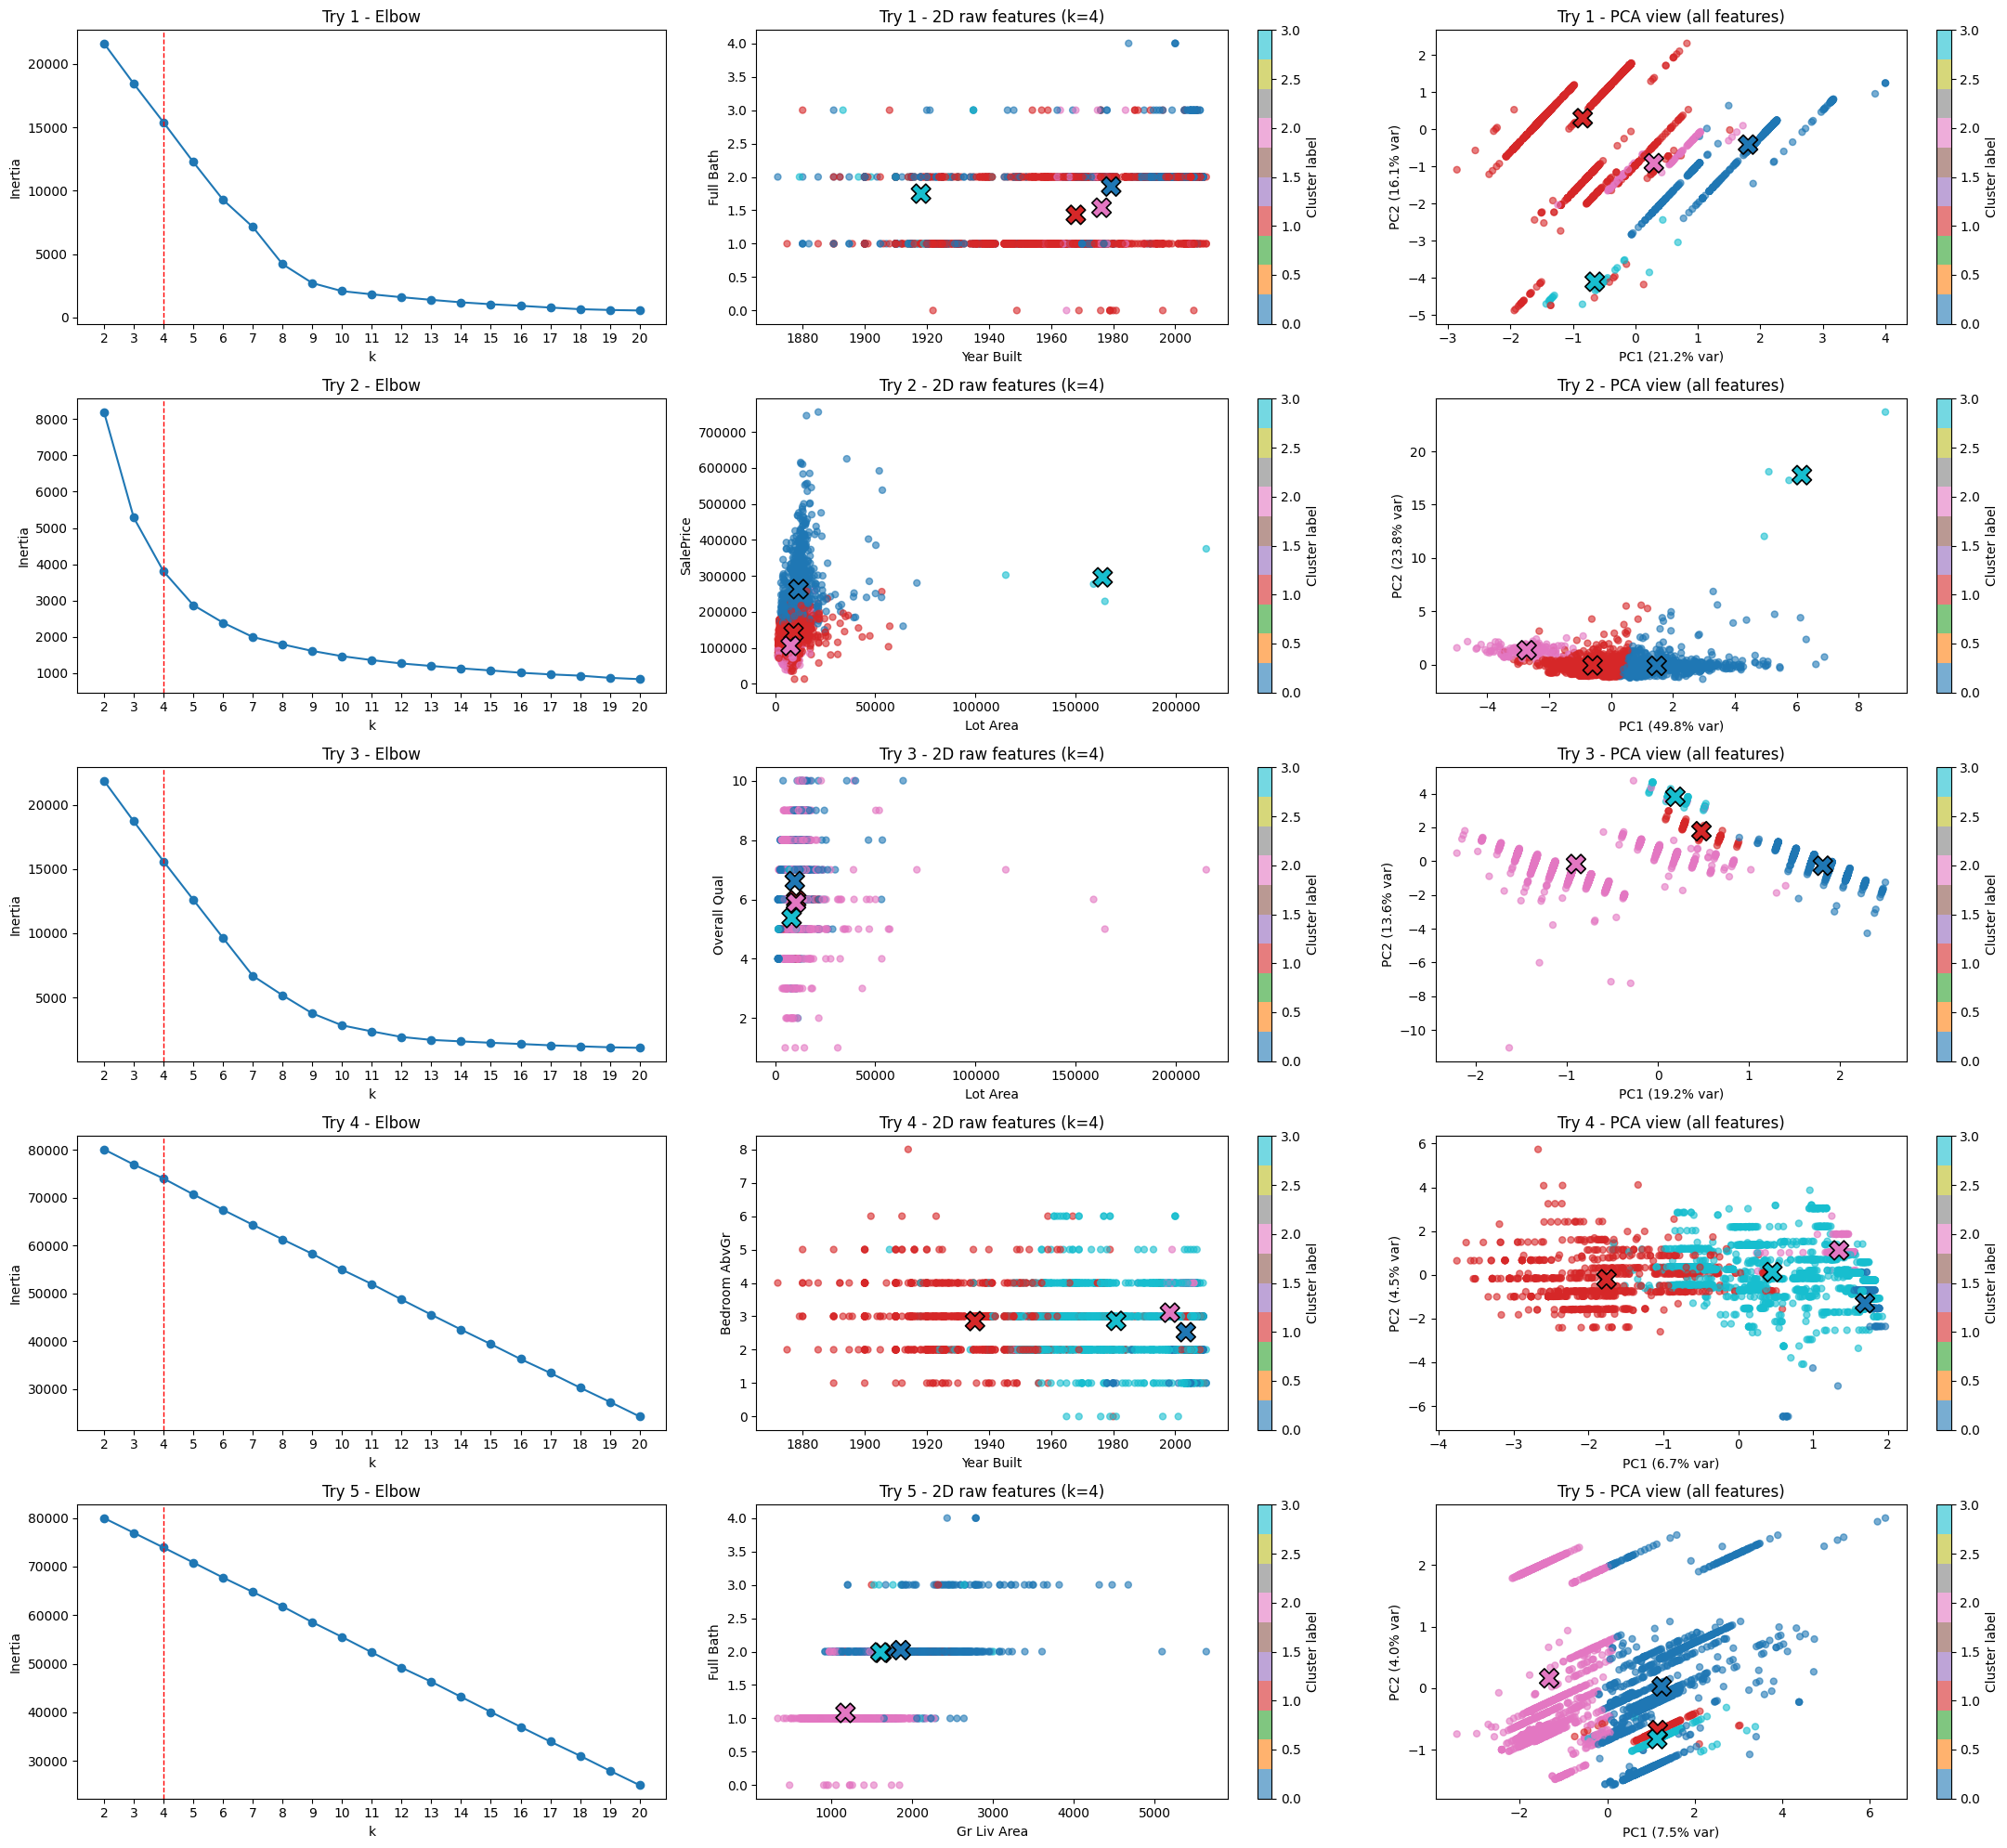

In [133]:
# Create one row per try: elbow plot + 2-feature scatter + PCA scatter (all features)
num_runs = len(results)
fig, axes = plt.subplots(num_runs, 3, figsize=(22, max(5, 4 * num_runs)))

# Make axes indexable when there is only one try
if num_runs == 1:
    axes = np.array([axes])

for row_idx, run in enumerate(results):
    ax_elbow = axes[row_idx, 0]
    ax_cluster_2d = axes[row_idx, 1]
    ax_cluster_pca = axes[row_idx, 2]

    # Plot elbow curve and highlight selected fixed k
    ax_elbow.plot(run["elbow_k_values"], run["elbow_inertias"], marker="o")
    ax_elbow.axvline(run["current_k"], color="red", linestyle="--", linewidth=1)
    ax_elbow.set_title(f"Try {run['dataset_index']} - Elbow")
    ax_elbow.set_xlabel("k")
    ax_elbow.set_ylabel("Inertia")
    ax_elbow.set_xticks(run["elbow_k_values"])  # Force whole-number ticks on x-axis

    # 2D scatter using first two raw features
    x_col, y_col = run["features"][0], run["features"][1]
    plot_df = run["data"].copy()
    plot_df["cluster"] = run["labels"]

    scatter_2d = ax_cluster_2d.scatter(
        plot_df[x_col],
        plot_df[y_col],
        c=plot_df["cluster"],
        cmap="tab10",
        alpha=0.6,
        s=25,
    )

    # Plot colored cluster centers with X marker (raw feature view)
    centers_df = run["centers_df"]
    center_colors = centers_df["cluster"].values
    ax_cluster_2d.scatter(
        centers_df[x_col],
        centers_df[y_col],
        c=center_colors,
        cmap="tab10",
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    ax_cluster_2d.set_title(f"Try {run['dataset_index']} - 2D raw features (k={run['current_k']})")
    ax_cluster_2d.set_xlabel(x_col)
    ax_cluster_2d.set_ylabel(y_col)

    # Add cluster-color legend bar for this subplot
    cbar_2d = fig.colorbar(scatter_2d, ax=ax_cluster_2d)
    cbar_2d.set_label("Cluster label")

    # PCA view uses all features from the run
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(run["X_scaled"])
    centers_pca = pca.transform(run["model"].cluster_centers_)

    scatter_pca = ax_cluster_pca.scatter(
        X_pca[:, 0],
        X_pca[:, 1],
        c=run["labels"],
        cmap="tab10",
        alpha=0.6,
        s=25,
    )

    ax_cluster_pca.scatter(
        centers_pca[:, 0],
        centers_pca[:, 1],
        c=np.arange(run["current_k"]),
        cmap="tab10",
        marker="X",
        s=220,
        edgecolor="black",
        linewidth=1.2,
        zorder=5,
    )

    explained = pca.explained_variance_ratio_
    ax_cluster_pca.set_title(f"Try {run['dataset_index']} - PCA view (all features)")
    ax_cluster_pca.set_xlabel(f"PC1 ({explained[0] * 100:.1f}% var)")
    ax_cluster_pca.set_ylabel(f"PC2 ({explained[1] * 100:.1f}% var)")

    cbar_pca = fig.colorbar(scatter_pca, ax=ax_cluster_pca)
    cbar_pca.set_label("Cluster label")

# Final layout cleanup
plt.tight_layout()
plt.show()

## Distance series and mean distance per cluster

In [134]:
# Collect distance details from all tries
distance_series_list = []
distance_mean_list = []

for run in results:
    # Per-sample distance table
    distance_series_df = run["distance_series"].rename("distance_to_center").to_frame()
    distance_series_df["dataset_index"] = run["dataset_index"]
    distance_series_df["cluster"] = run["labels"]
    distance_series_df["sample_index"] = distance_series_df.index
    distance_series_list.append(distance_series_df.reset_index(drop=True))

    # Per-cluster mean distance table
    mean_df = run["distance_mean"].reset_index()
    mean_df.insert(0, "dataset_index", run["dataset_index"])
    distance_mean_list.append(mean_df)

# Merge all runs into two analysis tables
distance_series_all = pd.concat(distance_series_list, ignore_index=True)
distance_means_all = pd.concat(distance_mean_list, ignore_index=True)

print("Distance series (first 15 rows)")
display(distance_series_all.head(15))

print("Mean distance per cluster")
display(distance_means_all)

Distance series (first 15 rows)


,distance_to_center,dataset_index,cluster,sample_index
0,0.984752,1,1,0
1,0.976389,1,1,1
2,1.004540,1,1,2
3,1.157641,1,1,3
4,0.638052,1,0,4
5,0.668381,1,0,5
6,1.590919,1,1,6
7,1.403579,1,1,7
8,1.461967,1,1,8
9,0.698957,1,0,9


Mean distance per cluster


,dataset_index,cluster,mean_distance
0,1,0,1.170975
1,1,1,1.881916
2,1,2,1.096753
3,1,3,1.137107
4,2,0,1.128844
5,2,1,0.790020
6,2,2,0.839809
7,2,3,3.673707
8,3,0,0.896782
9,3,1,0.640806


## Cluster centers dataframe and center colors

In [135]:
# Combine centers from every try into one DataFrame
cluster_centers_all = pd.concat([run["centers_df"] for run in results], ignore_index=True)

# Assign a stable color name to each center by cluster id
cluster_centers_all["center_color"] = cluster_centers_all["cluster"].map(
    lambda c: f"tab:{['blue','orange','green','red','purple','brown','pink','gray','olive','cyan'][c % 10]}"
)

cluster_centers_all.head(20)

,dataset_index,cluster,Year Built,Full Bath,House Style_1.5Unf,House Style_1Story,House Style_2.5Fin,House Style_2.5Unf,House Style_2Story,House Style_SFoyer,...,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Gr Liv Area,center_color
0,1,0,1979.383562,1.856164,8.673617e-19,6.661338e-16,8.673617e-19,3.469447e-18,9.965753e-01,-3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:blue
1,1,1,1967.999474,1.432702,9.989485e-03,7.786540e-01,4.206099e-03,-2.775558e-17,-3.330669e-16,4.363828e-02,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:orange
2,1,2,1976.281250,1.539062,8.673617e-19,-1.110223e-16,-8.673617e-19,1.734723e-18,-5.551115e-17,3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:green
3,1,3,1918.125000,1.750000,8.673617e-19,0.000000e+00,-4.336809e-19,1.000000e+00,0.000000e+00,3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:red
4,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:blue
5,2,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:orange
6,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:green
7,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:red
8,3,0,NaN,NaN,0.000000e+00,5.551115e-16,4.336809e-19,3.469447e-18,1.000000e+00,-3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:blue
9,3,1,NaN,NaN,8.673617e-19,0.000000e+00,-1.301043e-18,1.734723e-18,-1.110223e-16,3.469447e-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,tab:orange


In [136]:
# Show current-k silhouette scores across all tries
fixed_k_scores = pd.DataFrame([
    {
        "dataset_index": run["dataset_index"],
        "current_k": run["current_k"],
        "current_silhouette": run["current_silhouette"],
        "num_features": len(run["features"]),
    }
    for run in results
]).sort_values("current_silhouette", ascending=False)

print("Fixed-k silhouette comparison")
display(fixed_k_scores)

best_run = fixed_k_scores.iloc[0]
print(f"Best run by silhouette: try {int(best_run['dataset_index'])}")
print(f"Current k: {int(best_run['current_k'])}")
print(f"Silhouette: {best_run['current_silhouette']:.4f}")

Fixed-k silhouette comparison


,dataset_index,current_k,current_silhouette,num_features
1,2,4,0.470178,4
2,3,4,0.464741,9
0,1,4,0.429125,9
3,4,4,0.134336,29
4,5,4,0.115950,29


Best run by silhouette: try 2
Current k: 4
Silhouette: 0.4702
